### Overview

This code takes different **urbanization scenarios**, provided in **pickle format** and generated by the previous code `wilcoxon_test_and_plot`, and creates various **graphs** to compare them.

The urbanization scenarios represent changes in imp %. For each scenario, it generates visualizations that compare the effects of different urbanization levels on runoff behavior.

The resulting plots offer a clear comparison between the different scenarios, helping to evaluate and understand how urbanization influences rainfall and discharge dynamics.


## Imports and files

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

In [9]:
# Define the directory and pickle file path


sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion"
save_dir = r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts\combined_shifts'
os.makedirs(save_dir, exist_ok=True)

# rain_shift_classes = [
#     ('low_imp_urbanization_1_0.pkl', 'urbanization_1_0', '23% urbanization'),
#     ('low_imp_urbanization_3_0.pkl', 'urbanization_1_5', '67% urbanization')]
#     ('horton_urbanization_3_0.pkl', 'urbanization_3_0', '81% urbanization')]


rain_shift_classes = [
    ('urbanization_1_0.pkl', 'urbanization_1_0', '39% urbanization'),
    ('urbanization_1_1.pkl', 'urbanization_1_1', '42% urbanization'),
    ('urbanization_1_2.pkl', 'urbanization_1_2', '46% urbanization'),
    ('urbanization_1_3.pkl', 'urbanization_1_3', '49% urbanization'),
    ('urbanization_1_4.pkl', 'urbanization_1_4', '53% urbanization'),
    ('urbanization_1_5.pkl', 'urbanization_1_5', '57% urbanization'),
    ('urbanization_2_0.pkl', 'urbanization_2_0', '73% urbanization'),
    ('urbanization_3_0.pkl', 'urbanization_3_0', '81% urbanization'),
    ('urbanization_5_0.pkl', 'urbanization_5_0', '87% urbanization')]

Pickle file D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion\all_events_direc_urbanization_5_0 does not exist.


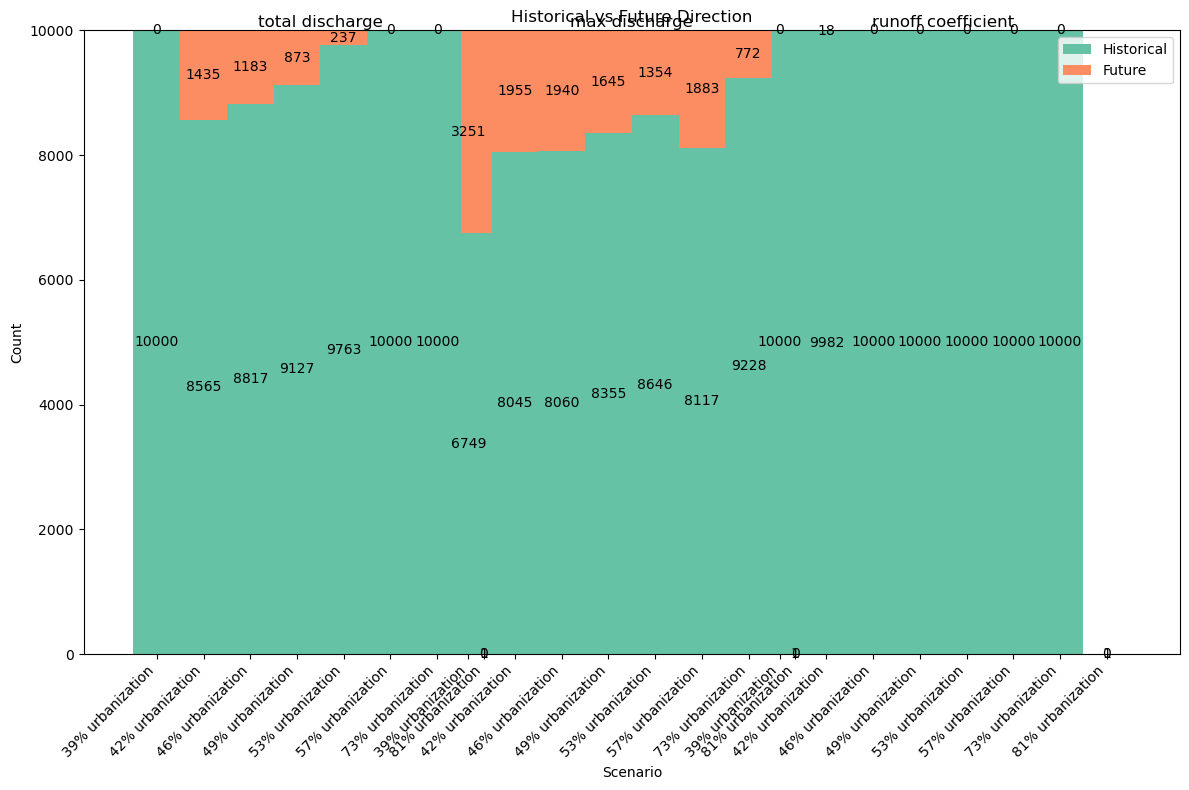

In [10]:
# Colors for historical and future data
historical_color = sns.color_palette("Set2")[0]
future_color = sns.color_palette("Set2")[1]

# Load data from pickle files
all_data = []
labels = []
for file_name, pickle_file, label_name in rain_shift_classes:
    pickle_file_path = os.path.join(sim_dir, f'all_events_direc_{pickle_file}')
    if os.path.exists(pickle_file_path):
        all_events_direc_df = pd.read_pickle(pickle_file_path)
        all_events_direc_df = all_events_direc_df.head(3)  # Use only the first 3 rows
        all_data.append(all_events_direc_df)
        labels.append(label_name)
    else:
        print(f"Pickle file {pickle_file_path} does not exist.")

# Initialize the figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the data
width = 0.15
n = len(all_data)
bar_positions = []
bar_labels = []

for i, (all_events_direc_df, label) in enumerate(zip(all_data, labels)):
    pos = [j + (i * width) for j in range(len(all_events_direc_df))]
    bar_positions.extend(pos)
    bar_labels.extend([label] * len(all_events_direc_df))

    # Plot without adding labels for the legend
    bars1 = ax.bar(pos, all_events_direc_df['historical_count'], width=width, color=historical_color)
    bars2 = ax.bar(pos, all_events_direc_df['future_count'], bottom=all_events_direc_df['historical_count'], width=width, color=future_color)

    # Adding annotations for the counts
    for bar, hist_count, fut_count in zip(bars1, all_events_direc_df['historical_count'], all_events_direc_df['future_count']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{hist_count}', ha='center', va='center', fontsize=10, color='black')
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + fut_count / 2, f'{fut_count}', ha='center', va='center', fontsize=10, color='black')

# Add metric labels above the bars
for i, metric in enumerate(all_data[0].index):
    # Calculate the average position for the metric across scenarios
    metric_positions = [
        bar_positions[j * len(all_data[0]) + i] for j in range(n)
    ]
    avg_position = sum(metric_positions) / len(metric_positions)
    
    # Calculate the maximum height for the metric across scenarios
    max_height = max(
        all_data[j]['historical_count'].iloc[i] + all_data[j]['future_count'].iloc[i]
        for j in range(n)
    )
    
    # Place the label above the bars
    ax.text(avg_position, max_height + 1, metric[1].replace("_"," "), ha='center', va='bottom', fontsize=12)

# Customize the plot
plt.title('Historical vs Future Direction')
plt.xlabel('Scenario')
plt.ylabel('Count')

# Set x-ticks positions and labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels, rotation=45, ha='right')

# Create custom legend
hist_patch = plt.Rectangle((0, 0), 1, 1, fc=historical_color, edgecolor='none', label='Historical')
future_patch = plt.Rectangle((0, 0), 1, 1, fc=future_color, edgecolor='none', label='Future')
plt.legend(handles=[hist_patch, future_patch])

plt.tight_layout()

# Save the plot

barplot_path = os.path.join(save_dir, 'all_events_direction_bar_plot_combined.png')
plt.savefig(barplot_path)
plt.show()


## significant

In [4]:
# Colors for historical and future data
historical_color = sns.color_palette("Set2")[0]
future_color = sns.color_palette("Set2")[1]

# Load data from pickle files
significant_data = []
labels = []  # To store the labels for each DataFrame
for file_name, pickle_file, label_name in rain_shift_classes:
    pickle_file_path = os.path.join(sim_dir, f'significant_events_direc_{pickle_file}')
    if os.path.exists(pickle_file_path):
        significant_events_direc_df = pd.read_pickle(pickle_file_path)
        # Slice the DataFrame to include only the first three rows
        significant_events_direc_df = significant_events_direc_df.head(3)
        significant_data.append(significant_events_direc_df)
        labels.append(label_name)
    else:
        print(f"Pickle file {pickle_file_path} does not exist.")

Pickle file D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion\significant_events_direc_urbanization_5_0 does not exist.


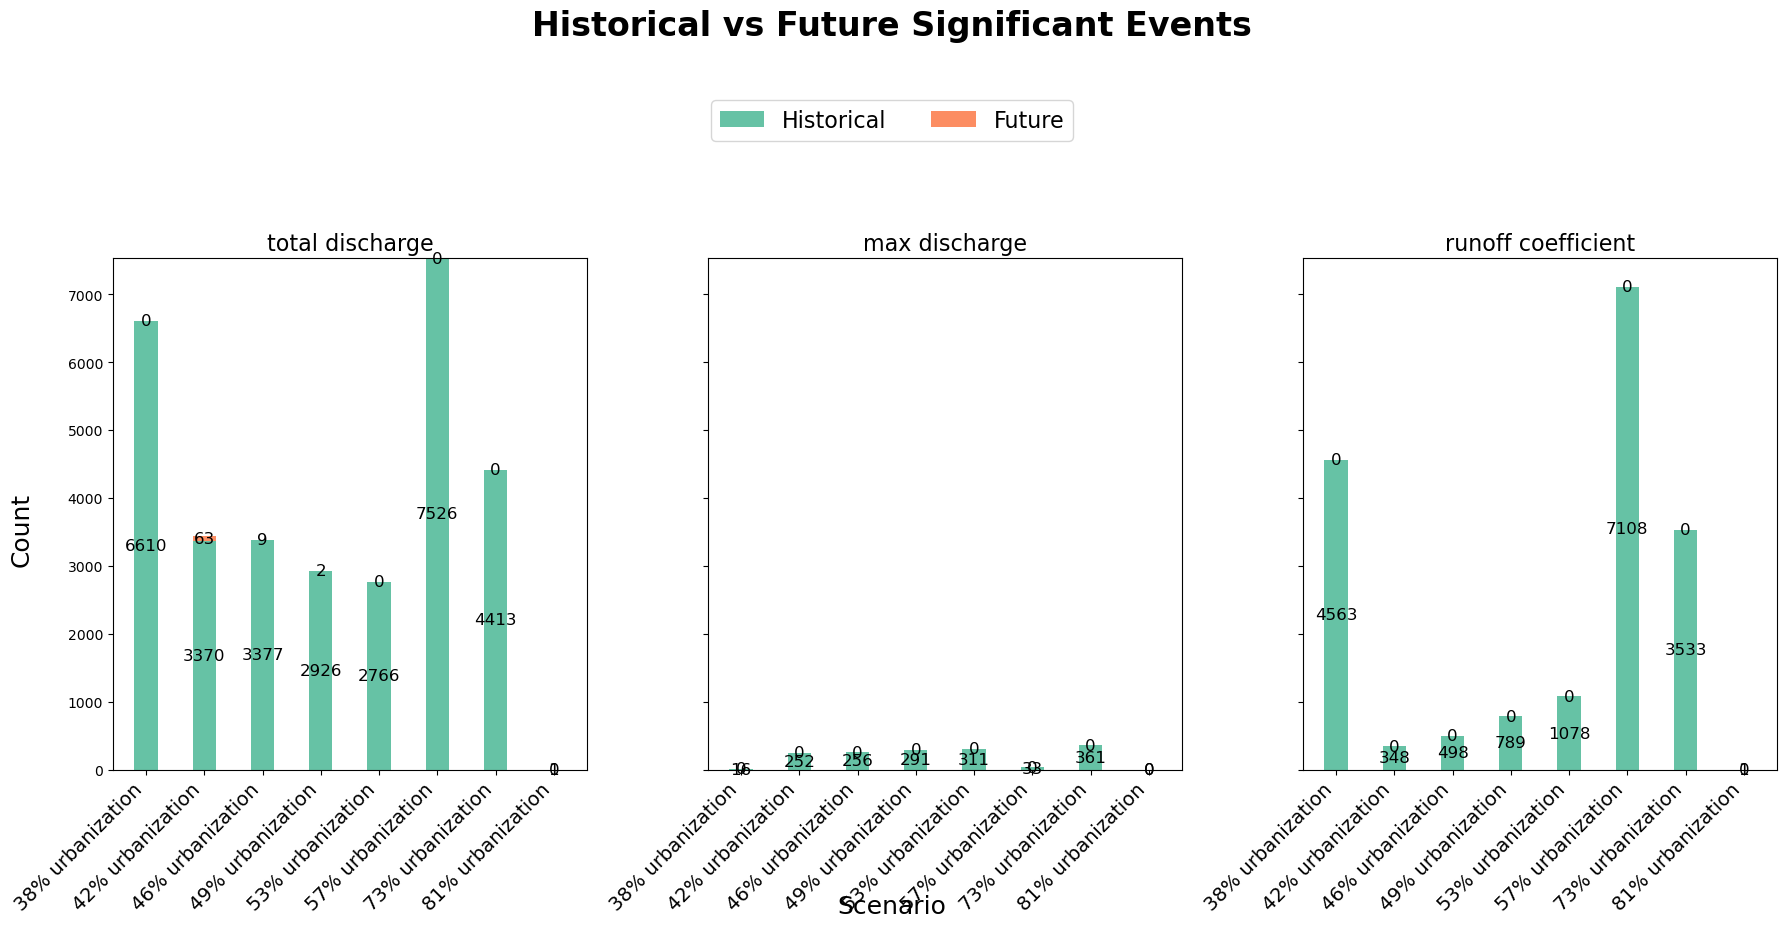

In [5]:

# Initialize the directory to save the subplots
subplots_dir = os.path.join(save_dir, 'subplots_by_metric')
os.makedirs(subplots_dir, exist_ok=True)

# Create subplots for each metric
metrics = significant_data[0].index  # Assuming all metrics are consistent across datasets
fig, axes = plt.subplots(1, len(metrics), figsize=(len(metrics) * 6, 8), sharey=True)

for metric, ax in zip(metrics, axes):
    bar_positions = []
    bar_labels = []
    historical_values = []
    future_values = []
    
    # Collect data for the specific metric across all labels
    for i, (significant_events_direc_df, label) in enumerate(zip(significant_data, labels)):
        historical_values.append(significant_events_direc_df['historical_count'].loc[metric])
        future_values.append(significant_events_direc_df['future_count'].loc[metric])
        bar_positions.append(i)
        bar_labels.append(label)
    
    # Plot the data for the specific metric
    bars1 = ax.bar(bar_positions, historical_values, width=0.4, color=historical_color, label='Historical')
    bars2 = ax.bar(bar_positions, future_values, bottom=historical_values, width=0.4, color=future_color, label='Future')
    
    # Add annotations for counts
    for bar, hist_count, fut_count in zip(bars1, historical_values, future_values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, f'{hist_count}', ha='center', va='center', fontsize=12, color='black')
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + fut_count / 2, f'{fut_count}', ha='center', va='center', fontsize=12, color='black')
    
    # Set x-ticks and labels
    ax.set_xticks(bar_positions)
    ax.set_xticklabels(bar_labels, rotation=45, ha='right', fontsize=14)
    
    # Set subplot titles
    ax.set_title(metric[1].replace("_", " "), fontsize=16)

# Set common labels
fig.text(0.5, 0.02, 'Scenario', ha='center', fontsize=18)
fig.text(0.01, 0.5, 'Count', va='center', rotation='vertical', fontsize=18)

# Add a main title and position the legend
fig.suptitle('Historical vs Future Significant Events', fontsize=24, weight='bold', y=1.15)

# Add a shared legend below the title
handles = [
    plt.Rectangle((0, 0), 1, 1, fc=historical_color, edgecolor='none', label='Historical'),
    plt.Rectangle((0, 0), 1, 1, fc=future_color, edgecolor='none', label='Future')
]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, fontsize=16)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust rect to fit everything nicely

# Save and show the plot
subplot_path = os.path.join(save_dir, 'significant_events_direction_bar_plot.png')
plt.savefig(subplot_path)
plt.show()


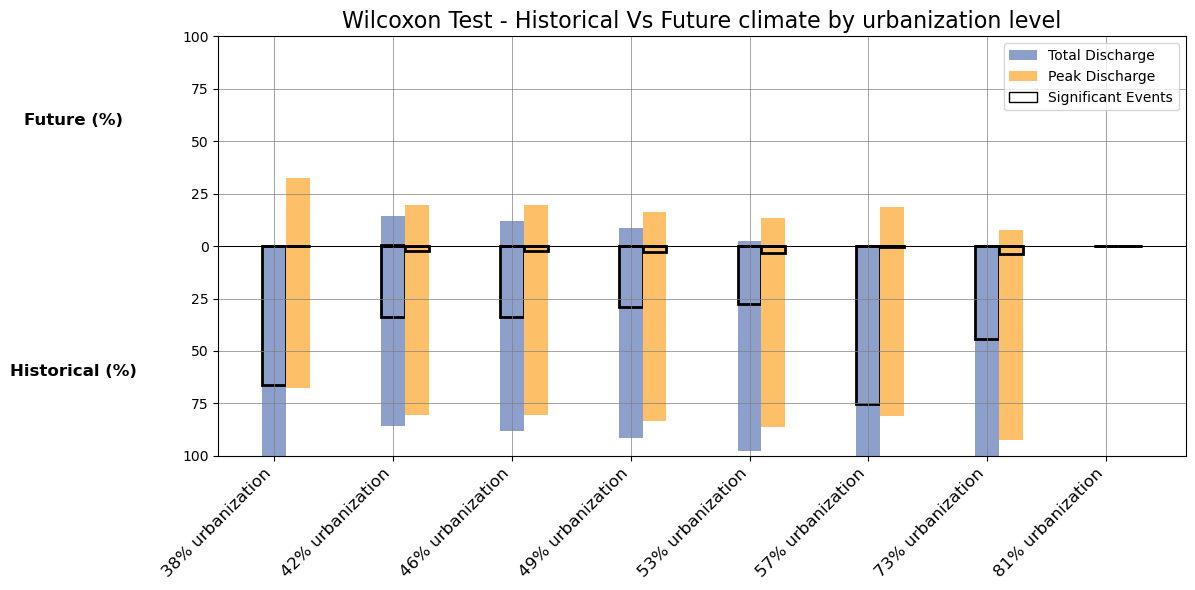

In [6]:
# Define the directory to save the plot
combined_plot_dir = os.path.join(save_dir, 'combined_metric_plot')
os.makedirs(combined_plot_dir, exist_ok=True)

# Define colors: one for total and one for max
color_total = '#8DA0CB'  # Blue
color_max = '#FDBF68'    # Orange

# Prepare data
metrics = significant_data[0][0:2].index  # Assuming all metrics are consistent across datasets
bar_width = 0.2
bar_positions = np.arange(len(labels))

# Find the position for the vertical line
last_climate_index = -1
for idx, label in enumerate(labels):
    if "Climate" not in label:
        last_climate_index = idx

# Calculate the position for the vertical line (midpoint between the last "Climate" label and the next one)
if last_climate_index != -1 and last_climate_index + 1 < len(labels):
    vertical_line_position = last_climate_index + 0.5
else:
    vertical_line_position = None  # No vertical line needed if no "Climate" labels are found

# Create a shortened version of labels
short_labels = []
for label in labels:
    if "Climate" in label:
        short_labels.append(label.split('Climate Chagne ')[-1])  # Extract the part after "Climate Change"
    else:
        short_labels.append(label)

# Create a figure
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each metric as a separate group of bars
for i, metric in enumerate(metrics):
    historical_all = [all_events_direc_df['historical_count'].loc[metric] / 10000 * 100 for all_events_direc_df in all_data]
    future_all = [all_events_direc_df['future_count'].loc[metric] / 10000 * 100 for all_events_direc_df in all_data]
    historical_sig = [significant_events_direc_df['historical_count'].loc[metric] / 10000 * 100 for significant_events_direc_df in significant_data]
    future_sig = [significant_events_direc_df['future_count'].loc[metric] / 10000 * 100 for significant_events_direc_df in significant_data]
    
    # Determine the label for each metric
    label = metric[1] if isinstance(metric, tuple) else metric
    
    # Determine the color based on the metric index (0: Total, 1: Max)
    bar_color = color_total if i == 0 else color_max
    
    # Plot historical values
    ax.bar(bar_positions + i * bar_width, [-val for val in historical_all],
           width=bar_width, color=bar_color, label=f'{label} (Historical)' if i == 0 else "")
    
    # Plot future values
    ax.bar(bar_positions + i * bar_width, future_all,
           width=bar_width, color=bar_color, label=f'{label} (Future)' if i == 0 else "")

    # Overlay significant historical values
    ax.bar(bar_positions + i * bar_width, [-val for val in historical_sig],
           width=bar_width, edgecolor='black', linewidth=2, fill=False)
    
    # Overlay significant future values
    ax.bar(bar_positions + i * bar_width, future_sig,
           width=bar_width, edgecolor='black', linewidth=2, fill=False)

# Add the vertical line if applicable
if vertical_line_position is not None:
    ax.axvline(x=vertical_line_position, color='black', linestyle='--', linewidth=2, label='Climate Change Boundary')

# Add horizontal line at X=0
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.75)

# Adjust y-axis ticks to show percentages
ax.set_ylim(-100, 100)
y_ticks = ax.get_yticks()
ax.set_yticks(y_ticks)
ax.set_yticklabels([abs(int(tick)) for tick in y_ticks])

# Add labels for "Future" and "Historical" at a fixed height
ax.text(-0.15, 80 / ax.get_ylim()[1], 'Future (%)', transform=ax.transAxes, fontsize=12, weight='bold', ha='center', va='center')
ax.text(-0.15, 20 / ax.get_ylim()[1], 'Historical (%)', transform=ax.transAxes, fontsize=12, weight='bold', ha='center', va='center')

# Add gridlines for clarity
ax.grid(linewidth=0.5, color='gray')

# Set x-ticks and labels
ax.set_xticks(bar_positions)
ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=12)

# Add split labels for the x-axis
if vertical_line_position is not None:
    ax.text(vertical_line_position - 3, -195, 'Historical climate', fontsize=12, weight='bold', ha='center')
    ax.text(vertical_line_position + 3, -195, 'Future climate', fontsize=12, weight='bold', ha='center')

# Set axis labels and title

ax.set_title('Wilcoxon Test - Historical Vs Future climate by urbanization level', fontsize=16)


# Simplify the legend to include two types
handles = [
    Patch(facecolor=color_total, label='Total Discharge'),
    Patch(facecolor=color_max, label='Peak Discharge'),
    Patch(facecolor='none', edgecolor='black', label='Significant Events')
]

# Update the legend
ax.legend(handles=handles, loc='upper right', fontsize=10)


# Adjust layout and save the plot
plt.tight_layout()
combined_plot_path = os.path.join(combined_plot_dir, 'combined_metrics_percentage_plot.png')
plt.savefig(combined_plot_path, dpi=300)  # Save with high DPI for clarity
plt.show()

In [7]:
combined_plot_dir

'D:\\Development\\RESEARCH\\Raanana\\figures\\climate_change_shifts\\combined_shifts\\combined_metric_plot'

In [8]:
all_events_direc_df

historical_count  future_count  \
basin discharge total_discharge                    1             0   
                max_discharge                      1             0   
                runoff_coefficient                 1             0   

                                        historical_top_3_events  \
basin discharge total_discharge     {'04': 1, '25': 1, '11': 1}   
                max_discharge       {'09': 1, '15': 1, '17': 1}   
                runoff_coefficient  {'31': 1, '23': 1, '24': 1}   

                                   future_top_3_events  
basin discharge total_discharge                     {}  
                max_discharge                       {}  
                runoff_coefficient                  {}